In [8]:
!pip install shap

In [9]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

In [10]:
# Configuration
MASTER_PATH = "../data/master"
MODELS_PATH = "../models"
REPORTS_PATH = "../reports"

os.makedirs(REPORTS_PATH, exist_ok=True)

EXPLAINABILITY - SHAP ANALYSIS

 Loading model and data...
 Model loaded: Random Forest
 Dataset: (13632, 47)
 Features: 46

 Using 500 samples for SHAP analysis

 Computing SHAP values...
 SHAP values computed: (500, 46)


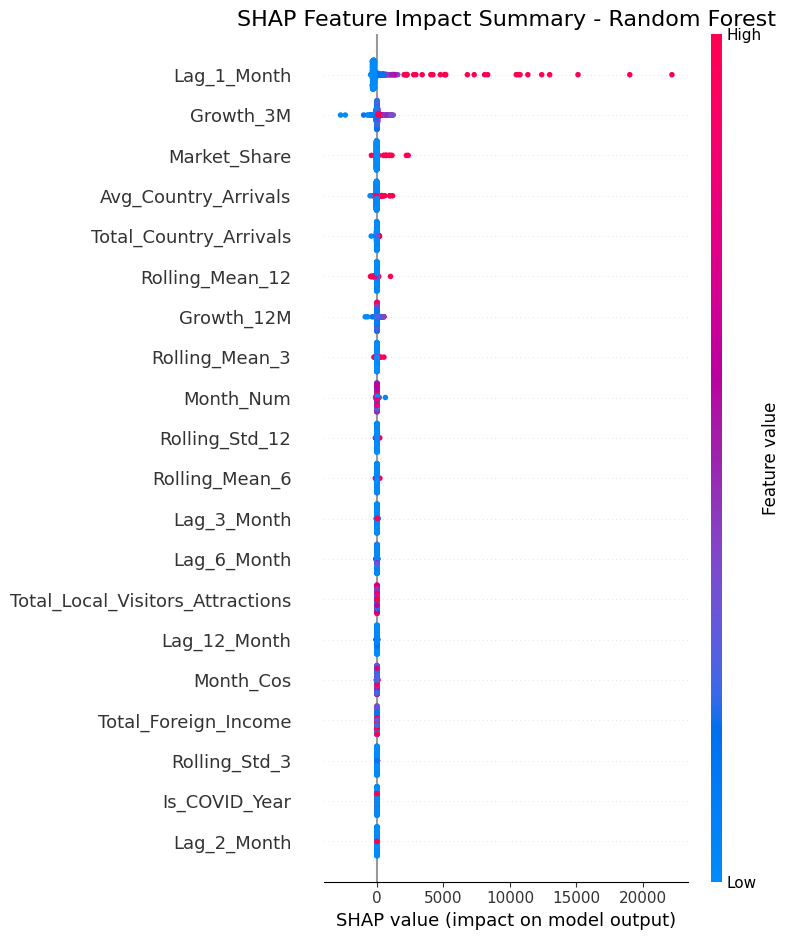

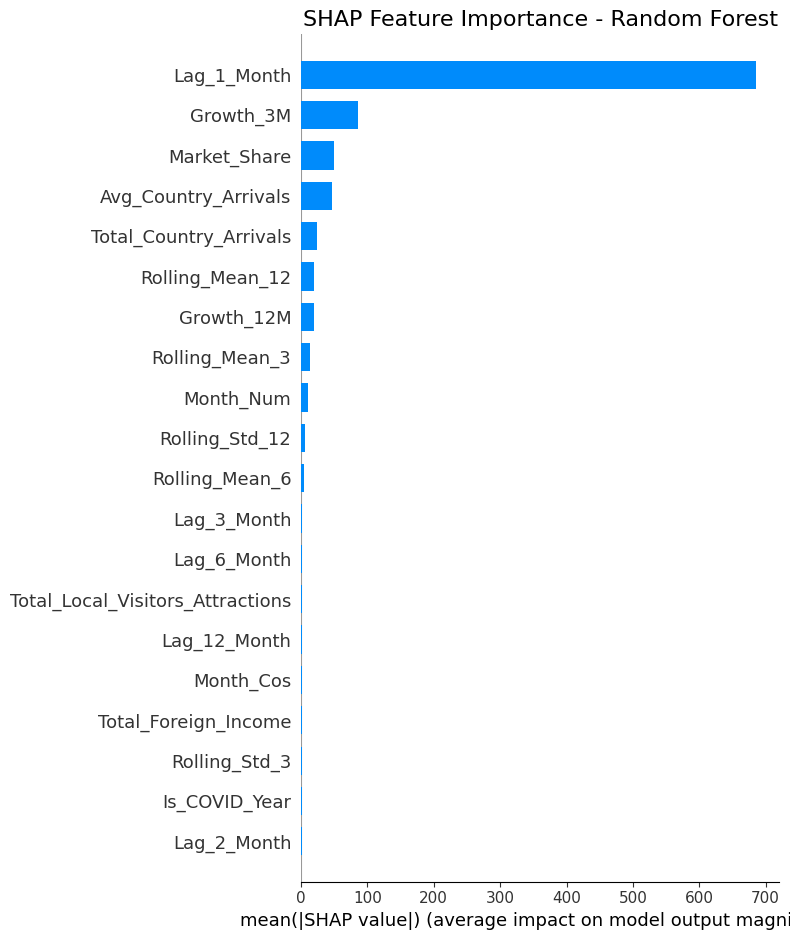


 Top 10 features by SHAP value:
               feature  mean_abs_shap
           Lag_1_Month     686.137068
             Growth_3M      86.365102
          Market_Share      49.165017
  Avg_Country_Arrivals      46.690595
Total_Country_Arrivals      23.767980
       Rolling_Mean_12      20.128542
            Growth_12M      19.776357
        Rolling_Mean_3      13.932801
             Month_Num      10.151490
        Rolling_Std_12       6.240172


<Figure size 1000x600 with 0 Axes>

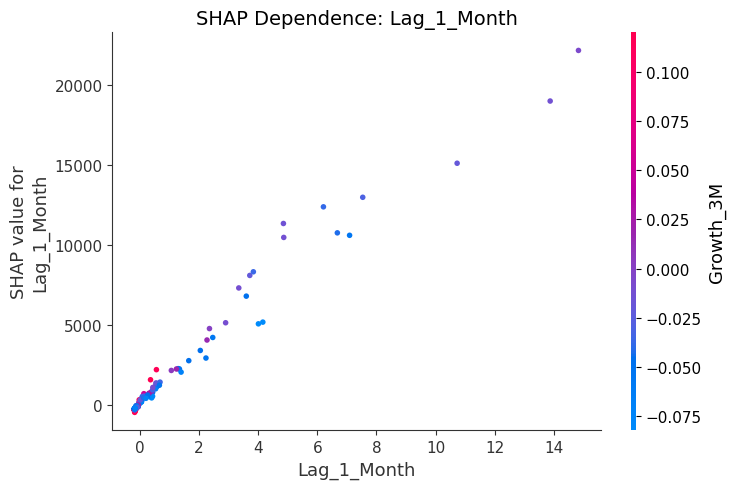

<Figure size 1000x600 with 0 Axes>

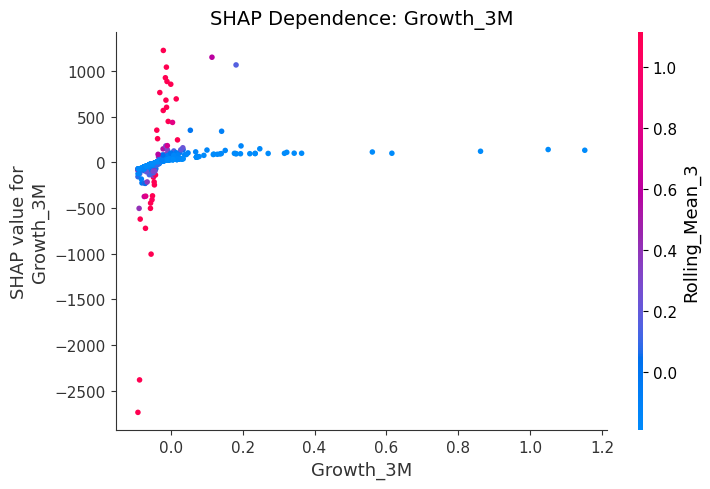

<Figure size 1000x600 with 0 Axes>

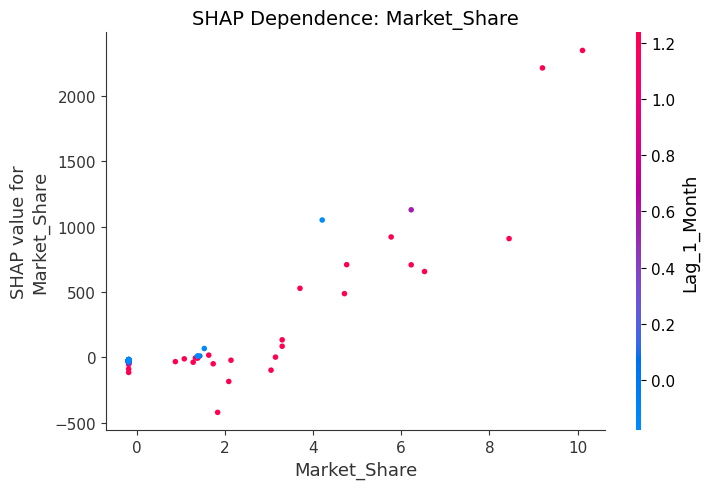

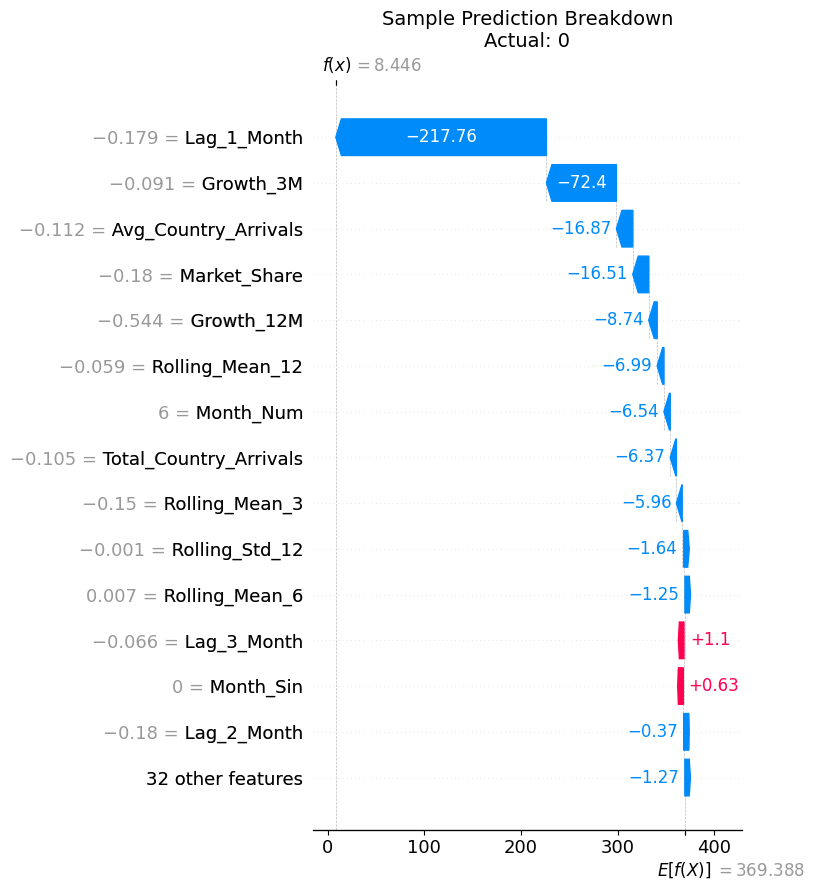


 SHAP analysis complete!

 Reports saved to: ../reports


In [11]:
print("="*60)
print("EXPLAINABILITY - SHAP ANALYSIS")
print("="*60)

# Load model and data
print("\n Loading model and data...")

model = joblib.load(f"{MODELS_PATH}/random_forest_final.pkl")
scaler = joblib.load(f"{MODELS_PATH}/scaler_final.pkl")
features = joblib.load(f"{MODELS_PATH}/feature_list_final.pkl")

df = pd.read_csv(f"{MASTER_PATH}/tourism_master_final.csv")

print(f" Model loaded: Random Forest")
print(f" Dataset: {df.shape}")
print(f" Features: {len(features)}")

# Prepare data
X = df[features]
y = df['Tourist_Arrivals']

# Use sample for SHAP (500 samples)
X_sample = X.sample(min(500, len(X)), random_state=42)
y_sample = y.loc[X_sample.index]

print(f"\n Using {len(X_sample)} samples for SHAP analysis")

# Scale the sample
binary_cols = ['Is_Top10', 'Is_Consistent_Top10', 'Is_Peak_Month', 
               'Is_COVID_Year', 'Is_Post_COVID']
categorical_cols = [col for col in features if col.startswith('Quarter_')]

cols_to_scale = [col for col in features 
                 if col not in binary_cols + categorical_cols 
                 and col not in ['Year', 'Month_Num', 'Country_Code']
                 and not col.endswith('_log')]

X_sample_scaled = X_sample.copy()
X_sample_scaled[cols_to_scale] = scaler.transform(X_sample[cols_to_scale])

# ============================================
# SHAP ANALYSIS
# ============================================
print("\n Computing SHAP values...")

# Create explainer (use TreeExplainer for Random Forest)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample_scaled)

print(f" SHAP values computed: {shap_values.shape}")

# 1. SHAP Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample_scaled, feature_names=features, show=False)
plt.title('SHAP Feature Impact Summary - Random Forest', fontsize=16)
plt.tight_layout()
plt.savefig(f"{REPORTS_PATH}/shap_summary_final.png", dpi=150)
plt.show()

# 2. SHAP Bar Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample_scaled, feature_names=features, 
                  plot_type="bar", show=False)
plt.title('SHAP Feature Importance - Random Forest', fontsize=16)
plt.tight_layout()
plt.savefig(f"{REPORTS_PATH}/shap_importance_final.png", dpi=150)
plt.show()

# 3. Feature importance dataframe
shap_importance = pd.DataFrame({
    'feature': features,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("\n Top 10 features by SHAP value:")
print(shap_importance.head(10).to_string(index=False))

# 4. Dependence plots for top features
top_features = shap_importance.head(3)['feature'].tolist()

for feature in top_features:
    plt.figure(figsize=(10, 6))
    shap.dependence_plot(feature, shap_values, X_sample_scaled, 
                         feature_names=features, show=False)
    plt.title(f'SHAP Dependence: {feature}', fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{REPORTS_PATH}/shap_dependence_{feature}.png", dpi=150)
    plt.show()

# 5. Waterfall plot for a sample prediction
idx = 0
shap_values_instance = shap_values[idx]
expected_value = explainer.expected_value

if isinstance(expected_value, np.ndarray):
    expected_value = expected_value[0]

plt.figure(figsize=(12, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_instance,
        base_values=expected_value,
        data=X_sample_scaled.iloc[idx].values,
        feature_names=features
    ),
    show=False,
    max_display=15
)
plt.title(f'Sample Prediction Breakdown\nActual: {y_sample.iloc[idx]:,.0f}', fontsize=14)
plt.tight_layout()
plt.savefig(f"{REPORTS_PATH}/shap_waterfall_sample.png", dpi=150)
plt.show()

print("\n SHAP analysis complete!")
print(f"\n Reports saved to: {REPORTS_PATH}")